# PSD Resolution Estimation — STEM-EDX-EELS Tomography

Workflow:
1. **Config** — paths, voxel size, axis map
2. **Load** — one TIFF per element / method
3. **Inspect axes** — real-space slices + PSD planes to confirm axis map
4. **PSD analysis** — compute 3D PSD and 1D profiles
5. **Resolution fitting** — Lorentzian fit per axis, collect results

## 0 — Imports

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path
from tifffile import imread
import sys, os

SRC_PATH = r"C:\Users\dd282367\AppData\Local\miniforge3\envs\torch_env\Lib\site-packages\DL_etomo\Src"
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

from psd_resolution import (
    reorder_vol_to_zyx,
    make_axis_labels,
    compute_psd_analysis,
    fit_lorentz_cutoff,
    plot_real_space,
    plot_psd_planes,
    plot_axis_profiles_1d,
    plot_axis_profiles_overlay,
    plot_lorentz_fit,
)

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# Colormaps
# ─────────────────────────────────────────────────────────────────────────────
CMAP_1  = LinearSegmentedColormap.from_list("core_magenta",  [(0,0,0), (1,0,1)], N=256)
CMAP_2 = LinearSegmentedColormap.from_list("shell_green",   [(0,0,0), (0,1,0)], N=256)


## 1 — Configuration

**Edit only this cell** between runs.

In [27]:
# ── File to analyse ──────────────────────────────────────────────────────────
DATA_DIR = Path(r"C:\Users\dd282367\AppData\Local\miniforge3\envs\torch_env\Lib\site-packages\DL_etomo\Data\PSD_test")

TIFF_PATH = DATA_DIR / "sirt1_30_2.tif"
# TIFF_PATH = DATA_DIR / "sirt1_60_2.tif"
# TIFF_PATH = DATA_DIR / "sirt1_90_2.tif"

# ── Voxel size (nm) ──────────────────────────────────────────────────────────
VOXEL_NM = 0.4
# ── Physical axis assignment ─────────────────────────────────────────────────
# Use the overlay plot (cell 3b) to decide:
#   Z = tilt / missing-wedge direction
#   Y, X = the other two
AXIS_MAP = {
    0: "X",
    1: "Y",
    2: "Z",
}

# ── PSD analysis parameters ──────────────────────────────────────────────────
PSD_PARAMS = dict(
    band           = 5,
    tail_frac_axis = (0.2, 0.2, 0.2),
    noise_mode     = "p80",
    tol_factor     = 1.0,
    k_min_frac     = 0.01,
    smooth_w       = 8,
)

# ── Lorentzian fit defaults (can be overridden per-axis below) ────────────────
FIT_DEFAULTS = dict(
    kmin            = 0.0,
    kmax_frac       = 0.99,
    min_pts         = 20,
    noise_tail_frac = 0.20,
    noise_kmax_frac = 1.0,
    choose_cut      = "last",
)

# ── Label for plots / results table ──────────────────────────────────────────
LABEL = TIFF_PATH.stem

# ── Output folder for saved SVGs (None = don't save) ─────────────────────────
OUT_DIR = None
# ── Results accumulator ────────────────────
if "lista_resol" not in dir():
    lista_resol = []

In [14]:
# ── File to analyse ──────────────────────────────────────────────────────────
# TIFF_PATH = Path(r"//kiev/share_nfs/200-Science_et_Technique/200.4-PFNC-DATA/zs247056 Kiev/resolution with 3D PSD/sirt1_30_2.tif")
TIFF_PATH = Path(r"//kiev/share_nfs/200-Science_et_Technique/200.4-PFNC-DATA/dd282367/2025_07_Tomo_EDX_B2_D3/velox_ali_l1/All_Frames/D3/1_sirt/SIRT_All_Frames_Te.tif")
# ── Voxel size (nm) ──────────────────────────────────────────────────────────
VOXEL_NM = 2*1.067
# ── Physical axis assignment ─────────────────────────────────────────────────
# Use the overlay plot (cell 3b) to decide:
#   Z = tilt / missing-wedge direction  (fastest PSD drop)
#   Y, X = the other two
AXIS_MAP = {
    0: "Y",
    1: "Z",
    2: "X",
}

# ── PSD analysis parameters ──────────────────────────────────────────────────
PSD_PARAMS = dict(
    band           = 5,
    tail_frac_axis = (0.2, 0.2, 0.2),
    noise_mode     = "p80",
    tol_factor     = 1.0,
    k_min_frac     = 0.01,
    smooth_w       = 8,
)

# ── Lorentzian fit defaults (can be overridden per-axis below) ────────────────
FIT_DEFAULTS = dict(
    kmin            = 0.0,
    kmax_frac       = 0.99,
    min_pts         = 20,
    noise_tail_frac = 0.20,
    noise_kmax_frac = 1.0,
    choose_cut      = "last",
)

# ── Label for plots / results table ──────────────────────────────────────────
LABEL = "SIRT_Ge"

# ── Output folder for saved SVGs (None = don't save) ─────────────────────────
OUT_DIR = None

# ── Results accumulator ────────────────────
if "lista_resol" not in dir():
    lista_resol = []

## 2 — Load volume

In [28]:
vol_raw = imread(str(TIFF_PATH)).astype(np.float32)
# replace NaN / Inf by 0 and clip negatives
vol_raw = np.nan_to_num(vol_raw, nan=0.0, posinf=0.0, neginf=0.0)
vol_raw = np.clip(vol_raw, 0, None)

print(f"Loaded : {TIFF_PATH.name}")
print(f"Shape  : {vol_raw.shape}   dtype={vol_raw.dtype}")
print(f"Range  : [{vol_raw.min():.3g}, {vol_raw.max():.3g}]")

Loaded : sirt1_30_2.tif
Shape  : (160, 160, 160)   dtype=float32
Range  : [0, 34.2]


voxel_nm = (VOXEL_NM, VOXEL_NM, VOXEL_NM) if np.isscalar(VOXEL_NM) else tuple(VOXEL_NM)

vol_zyx, perm = reorder_vol_to_zyx(vol_raw, AXIS_MAP)
lbls = make_axis_labels()

print(f"\nPhysical axis order after reorder: Z={vol_zyx.shape[0]} Y={vol_zyx.shape[1]} X={vol_zyx.shape[2]}")

In [29]:
voxel_nm = (VOXEL_NM, VOXEL_NM, VOXEL_NM) if np.isscalar(VOXEL_NM) else tuple(VOXEL_NM)

vol_zyx, perm = reorder_vol_to_zyx(vol_raw, AXIS_MAP)
lbls = make_axis_labels(AXIS_MAP)

print(f"\nPhysical axis order after reorder: Z={vol_zyx.shape[0]} Y={vol_zyx.shape[1]} X={vol_zyx.shape[2]}")

[reorder] [2, 1, 0]: (160, 160, 160) -> ZYX (160, 160, 160)

Physical axis order after reorder: Z=160 Y=160 X=160


## 3b — Visual axis check

**Real-space slices**: Z slice should show the sample cross-section you expect.  
**Profile overlay**: the red curve (kZ tilt) should drop fastest — if not, update `AXIS_MAP` in cell 1.

In [36]:
# Quick PSD just to see the overlay (fast, coarse params)
_out_check = compute_psd_analysis(
    vol_zyx, voxel_nm=voxel_nm,
    band=3, smooth_w=4, k_min_frac=0.001,
    tail_frac_axis=(0.3, 0.3, 0.4)
)

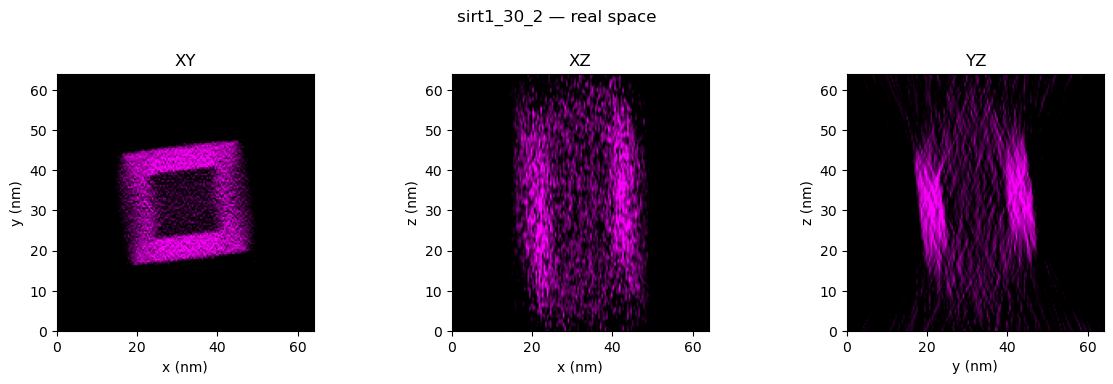

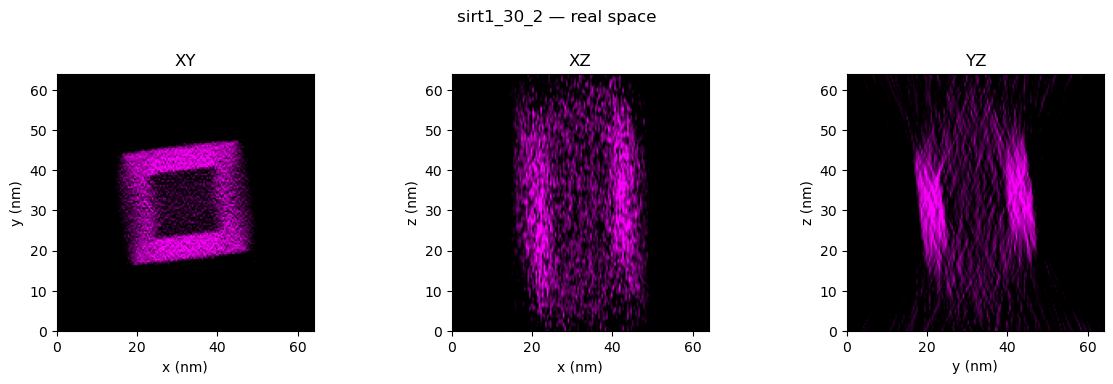

In [37]:
Z, Y, X = vol_zyx.shape
plot_real_space(
    vol_zyx,
    {"z0": 80, "y0": 80, "x0": 80},
    CMAP_1,
    voxel_nm=voxel_nm,
    title_prefix=f"{LABEL} — real space",
)
# plot_axis_profiles_overlay(_out_check, axis_labels=lbls)

## 4 — Full PSD analysis

In [38]:
out = compute_psd_analysis(vol_zyx, voxel_nm=voxel_nm, **PSD_PARAMS)

nyq = out["axes"]["nyquist"]
print(f"Nyquist: kx={nyq[0]:.3f}  ky={nyq[1]:.3f}  kz={nyq[2]:.3f} nm⁻¹")

for ax in ("kx", "ky", "kz"):
    kc = out["axis_1d"][ax]["kc"]
    res = 1/kc if np.isfinite(kc) and kc > 0 else float("nan")
    print(f"  quick cutoff  {ax}: kc={kc:.3g} nm⁻¹  →  {res:.2f} nm")

Nyquist: kx=1.250  ky=1.250  kz=1.250 nm⁻¹
  quick cutoff  kx: kc=0.474 nm⁻¹  →  2.11 nm
  quick cutoff  ky: kc=0.968 nm⁻¹  →  1.03 nm
  quick cutoff  kz: kc=1.01 nm⁻¹  →  0.99 nm


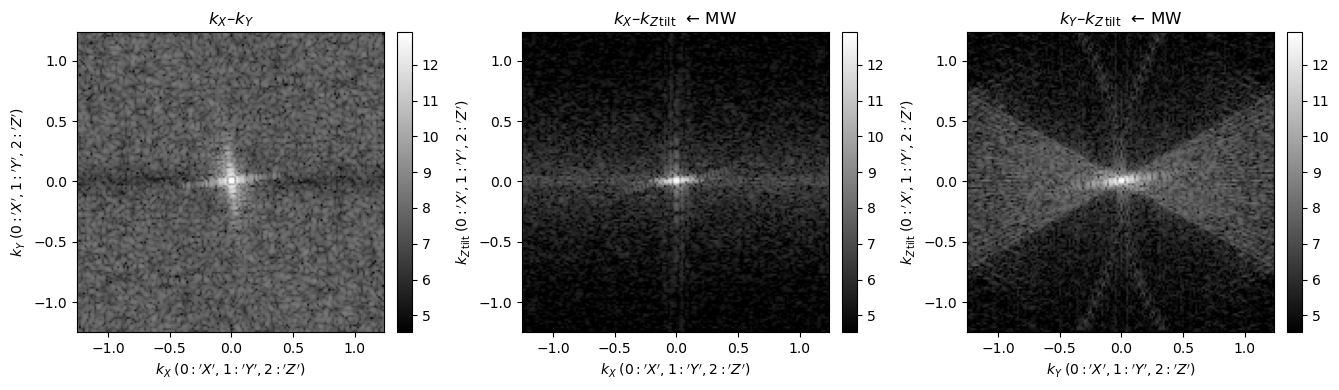

In [39]:
fig = plot_psd_planes(out, axis_labels=lbls)
if OUT_DIR:
    fig.savefig(Path(OUT_DIR) / f"{LABEL}_psd_planes.svg", bbox_inches="tight")

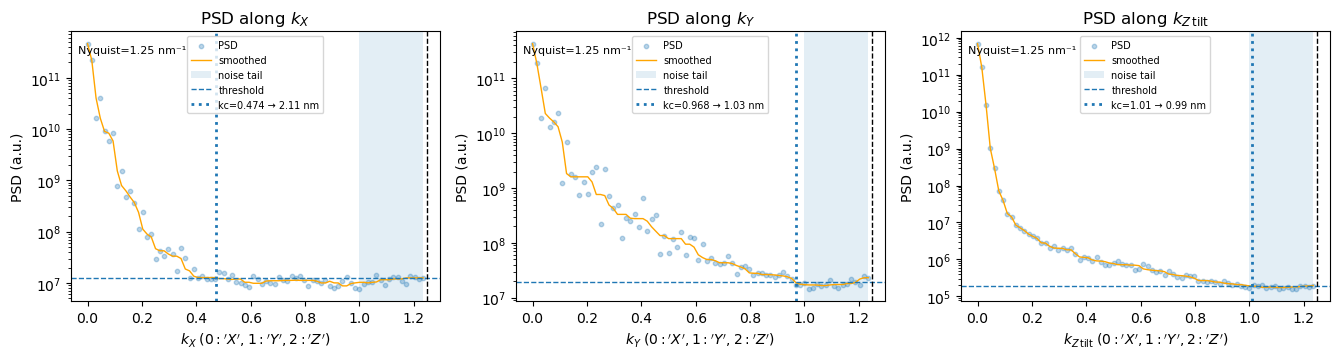

In [40]:
fig = plot_axis_profiles_1d(out, axis_labels=lbls)
if OUT_DIR:
    fig.savefig(Path(OUT_DIR) / f"{LABEL}_psd_profiles.svg", bbox_inches="tight")

## 5 — Resolution fitting

Run the three cells below (one per axis).  
Tune `noise_tail_frac` and `choose_cut` if the noise line or cutoff looks off.

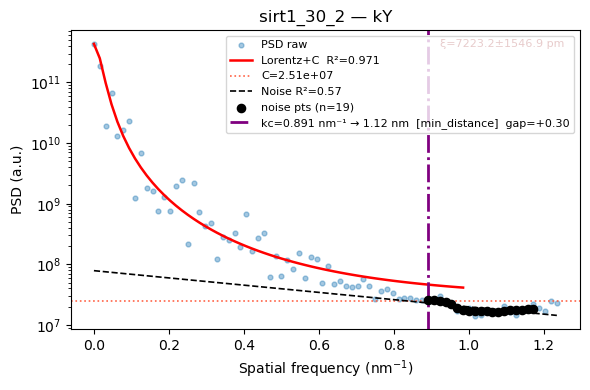

ky  [min_distance]  kc=0.8906 nm⁻¹  →  1.12 nm


In [78]:
# ── ky ───────────────────────────────────────────────────────────────────────
d  = out["axis_1d"]["ky"]
k  = np.asarray(d["k"], float)
sm = np.asarray(d["smooth"], float)

fit_ky = fit_lorentz_cutoff(k, sm,
        kmin = 0.0,
        kmax_frac = .8,
        min_pts = 20,
        noise_tail_frac = 0.25,
        noise_kmax_frac = 0.95,
        choose_cut = "last")

_save = str(Path(OUT_DIR) / f"{LABEL}_ky.svg") if OUT_DIR else None
plot_lorentz_fit(k, d, fit_ky, title=f"{LABEL} — kY", save_path=_save)

if fit_ky["ok"]:
    print(f"ky  [{fit_ky['cut_mode']}]  kc={fit_ky['k_cut']:.4f} nm⁻¹  →  {fit_ky['res_cut_nm']:.2f} nm")
    lista_resol.append([f"{LABEL}-kY", fit_ky["res_cut_nm"]])
else:
    print("ky fit failed:", fit_ky.get("reason"))

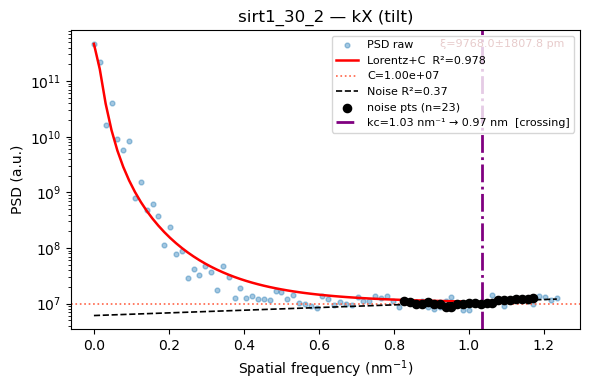

kx  [crossing]  kc=1.0343 nm⁻¹  →  0.97 nm


In [76]:
# ── kx ───────────────────────────────────────────────────────
d  = out["axis_1d"]["kx"]
k  = np.asarray(d["k"], float)
sm = np.asarray(d["smooth"], float)

# kz often needs a larger noise_tail_frac because the profile drops quickly
fit_kx = fit_lorentz_cutoff(k, sm,
        kmin = 0.0,
        kmax_frac = .8,
        min_pts = 20,
        noise_tail_frac = 0.3,
        noise_kmax_frac = 0.95,
        choose_cut = "last")

_save = str(Path(OUT_DIR) / f"{LABEL}_kx.svg") if OUT_DIR else None
plot_lorentz_fit(k, d, fit_kx, title=f"{LABEL} — kX (tilt)", save_path=_save)

if fit_kx["ok"]:
    print(f"kx  [{fit_kx['cut_mode']}]  kc={fit_kx['k_cut']:.4f} nm⁻¹  →  {fit_kx['res_cut_nm']:.2f} nm")
    lista_resol.append([f"{LABEL}-kZ", fit_kx["res_cut_nm"]])
else:
    print("kx fit failed:", fit_kx.get("reason"))

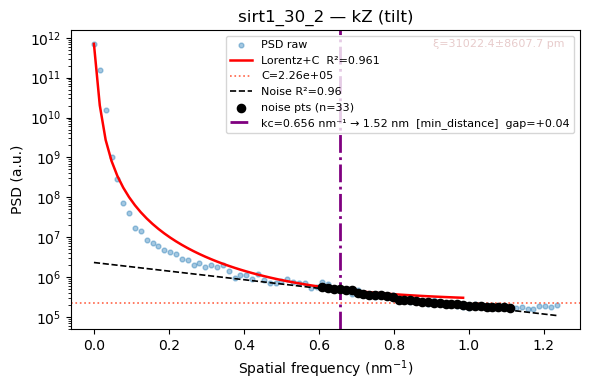

kz  [min_distance]  kc=0.6562 nm⁻¹  →  1.52 nm


In [82]:
# ── kz (tilt / MW axis) ───────────────────────────────────────────────────────
d  = out["axis_1d"]["kz"]
k  = np.asarray(d["k"], float)
sm = np.asarray(d["smooth"], float)

# kz often needs a larger noise_tail_frac because the profile drops quickly
fit_kz = fit_lorentz_cutoff(k, sm,
        kmin = 0.0,
        kmax_frac = 0.8,
        min_pts = 20,
        noise_tail_frac = 0.45,
        noise_kmax_frac = 0.9,
        choose_cut = "last")

_save = str(Path(OUT_DIR) / f"{LABEL}_kz.svg") if OUT_DIR else None
plot_lorentz_fit(k, d, fit_kz, title=f"{LABEL} — kZ (tilt)", save_path=_save)

if fit_kz["ok"]:
    print(f"kz  [{fit_kz['cut_mode']}]  kc={fit_kz['k_cut']:.4f} nm⁻¹  →  {fit_kz['res_cut_nm']:.2f} nm")
    lista_resol.append([f"{LABEL}-kZ", fit_kz["res_cut_nm"]])
else:
    print("kz fit failed:", fit_kz.get("reason"))